In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from pathlib import Path

Matplotlib created a temporary config/cache directory at /tmp/matplotlib-hkm0yand because the default path (/home/mi/marcelli/.cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.



=== Plotting from test_equilibration_one_instance.h5 ===


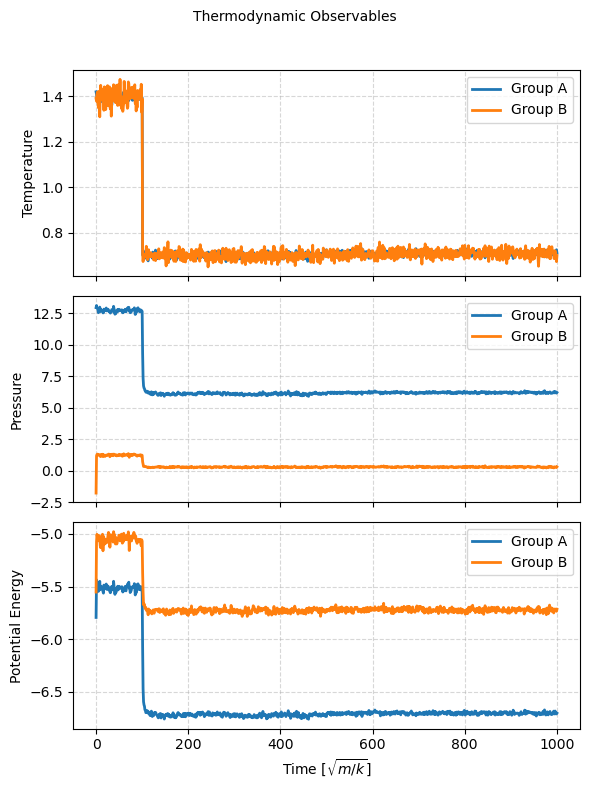

In [12]:
h5_files = ["modularity-test/test_equilibration_one_instance.h5"]

OBS_GROUPS = {
    "observables/A": "Group A",
    "observables/B": "Group B",
}
OBS_NAMES = {
    "temperature": r"Temperature",
    "pressure": r"Pressure",
    "potential_energy": r"Potential Energy",
}


def get_time_and_values(group, name):
    if name not in group:
        return None, None
    g = group[name]
    if "value" not in g:
        return None, None

    values = np.array(g["value"])
    if "time" in g:
        time = np.array(g["time"])
    elif "step" in g:
        time = np.array(g["step"], dtype=float)
    else:
        time = np.arange(values.shape[0], dtype=float)
    return time, values


for file in h5_files:
    print(f"\n=== Plotting from {Path(file).name} ===")
    with h5py.File(file, "r") as f:
        # One figure with 3 stacked subplots
        fig, axes = plt.subplots(len(OBS_NAMES), 1, figsize=(6, 8), sharex=True)

        for ax, (obs_key, obs_label) in zip(axes, OBS_NAMES.items()):
            for grp_path, grp_label in OBS_GROUPS.items():
                if grp_path not in f:
                    continue
                time, values = get_time_and_values(f[grp_path], obs_key)
                if time is None or values is None:
                    continue
                ax.plot(time, values, label=grp_label, linewidth=2)
                # print(values)
            ax.set_ylabel(obs_label, fontsize=10)
            ax.grid(True, linestyle="--", alpha=0.5)
            ax.legend(fontsize=10)

        axes[-1].set_xlabel(r"Time [$\sqrt{m/k}$]", fontsize=10)
        fig.suptitle("Thermodynamic Observables", fontsize=10)
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()



=== Numeric check @ Group A (tol=0.01) ===
- Group A | temperature: MISMATCH (max diff 1.690e-02 > 0.01)
    length compared: 11, max diff at index 9 (t ≈ 9)
    prod_one_instance.h5 avg.=0.711216, prod_two_instances.h5 avg.=0.711445, $\Delta$=0.000228631
- Group A | pressure: MISMATCH (max diff 3.028e-01 > 0.01)
    length compared: 11, max diff at index 7 (t ≈ 7)
    prod_one_instance.h5 avg.=6.2057, prod_two_instances.h5 avg.=6.43118, $\Delta$=0.225479
- Group A | potential_energy: MISMATCH (max diff 1.371e+00 > 0.01)
    length compared: 11, max diff at index 9 (t ≈ 9)
    prod_one_instance.h5 avg.=-6.70427, prod_two_instances.h5 avg.=-8.05014, $\Delta$=1.34587
- Group A | internal_energy: MISMATCH (max diff 1.355e+00 > 0.01)
    length compared: 11, max diff at index 6 (t ≈ 6)
    prod_one_instance.h5 avg.=-5.63744, prod_two_instances.h5 avg.=-6.98297, $\Delta$=1.34553


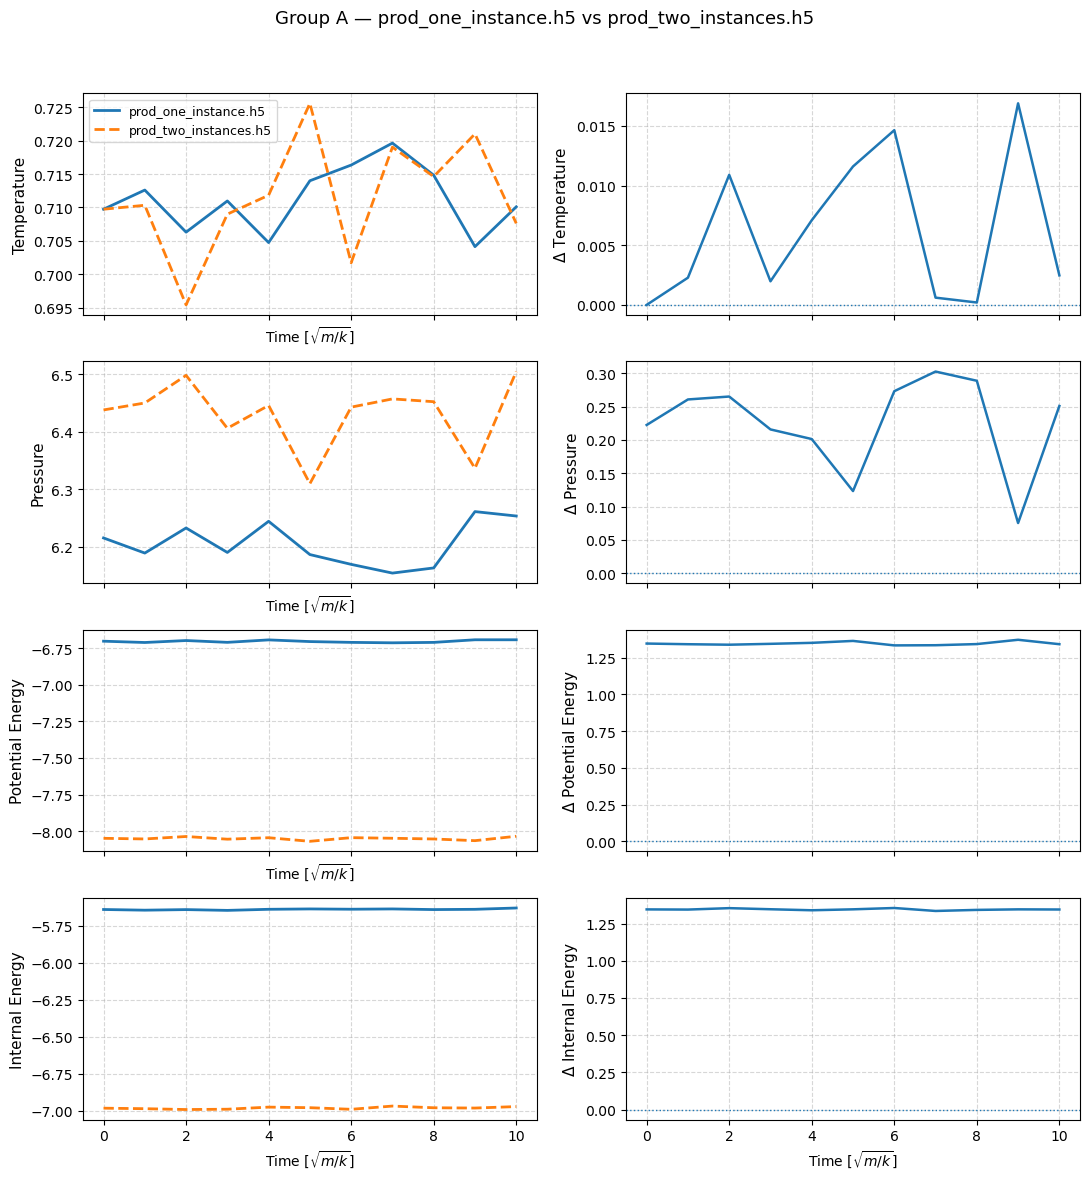


=== Numeric check @ Group B (tol=0.01) ===
- Group B | temperature: MISMATCH (max diff 3.738e-02 > 0.01)
    length compared: 11, max diff at index 6 (t ≈ 6)
    prod_one_instance.h5 avg.=0.698336, prod_two_instances.h5 avg.=0.711718, $\Delta$=0.0133817
- Group B | pressure: MISMATCH (max diff 2.799e-01 > 0.01)
    length compared: 11, max diff at index 8 (t ≈ 8)
    prod_one_instance.h5 avg.=0.293842, prod_two_instances.h5 avg.=0.505218, $\Delta$=0.211376
- Group B | potential_energy: MISMATCH (max diff 5.421e+00 > 0.01)
    length compared: 11, max diff at index 2 (t ≈ 2)
    prod_one_instance.h5 avg.=-5.71968, prod_two_instances.h5 avg.=-11.1136, $\Delta$=5.39387
- Group B | internal_energy: MISMATCH (max diff 5.416e+00 > 0.01)
    length compared: 11, max diff at index 5 (t ≈ 5)
    prod_one_instance.h5 avg.=-4.67218, prod_two_instances.h5 avg.=-10.046, $\Delta$=5.3738


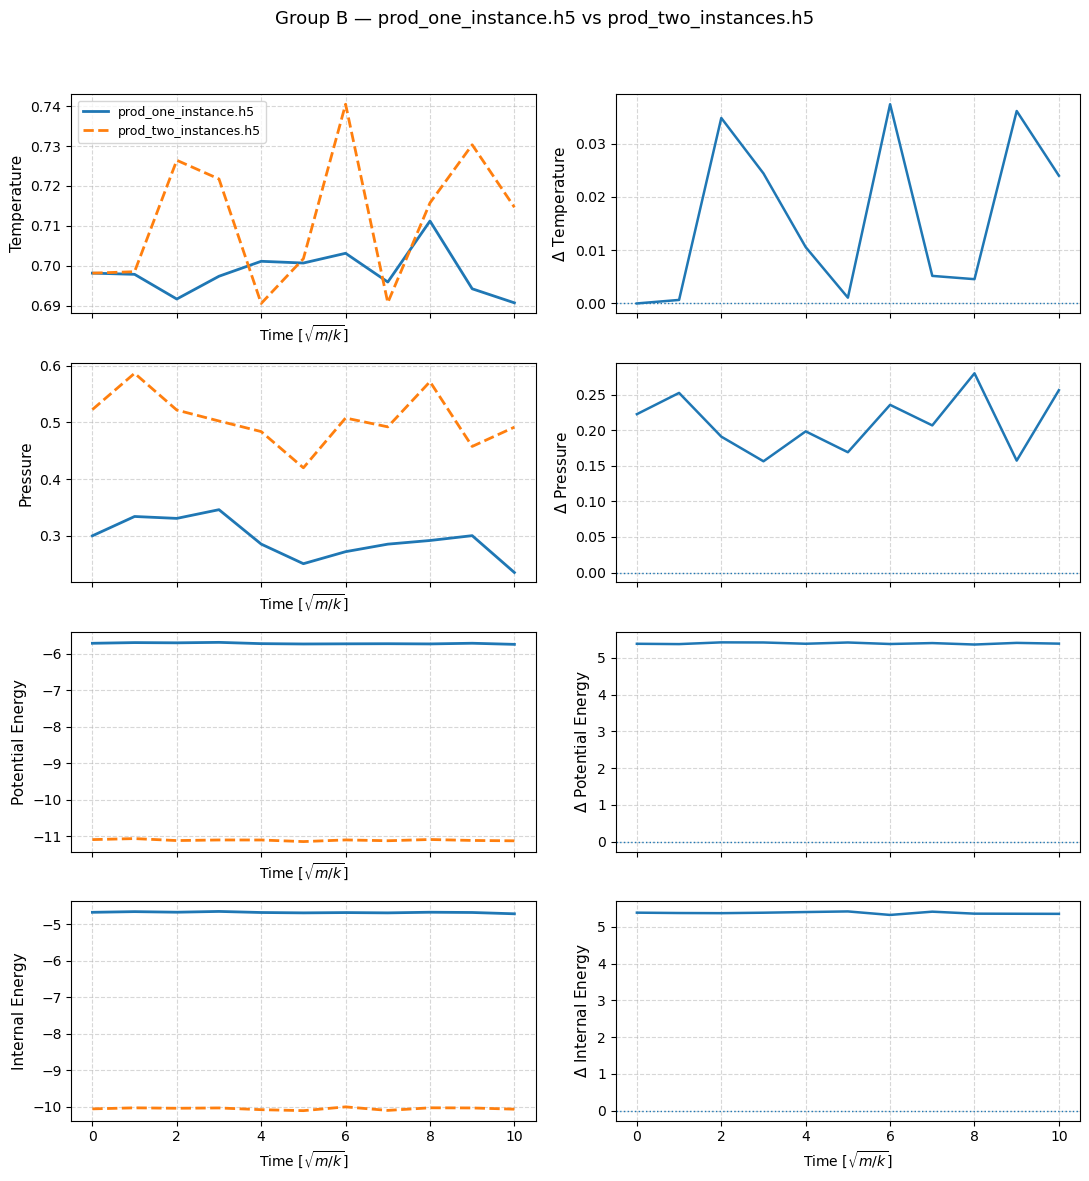

In [22]:
production_files = [
    "modularity-test/prod_one_instance.h5",
    "modularity-test/prod_two_instances.h5",
]
GROUPS = {"observables/A": "Group A", "observables/B": "Group B"}
OBS_TRY = ["temperature", "pressure", "potential_energy", "internal_energy"]
TOL = 1e-2  # absolute tolerance

# ==== HELPERS ====
def get_time_values(f, grp_path, obs):
    """Return (time, values) or (None, None) if missing."""
    if grp_path not in f or obs not in f[grp_path]:
        return None, None
    node = f[grp_path][obs]
    if "value" not in node:
        return None, None
    v = np.asarray(node["value"], dtype=float).reshape(-1)
    if "time" in node:
        t = np.asarray(node["time"], dtype=float).reshape(-1)
    elif "step" in node:
        t = np.asarray(node["step"], dtype=float).reshape(-1)
    else:
        t = np.arange(v.shape[0], dtype=float)
    # trim if needed
    n = min(len(t), len(v))
    return t[:n], v[:n]

def print_numeric_check(name1, name2, grp_label, obs, t1, v1, t2, v2):
    """Elementwise numeric check + brief summary and where the max diff is."""
    # Align for numeric comparison: use the shorter length if shapes differ
    n = min(v1.size, v2.size)
    a, b = v1[:n], v2[:n]
    same = np.allclose(a, b, atol=TOL, rtol=0.0)
    diffs = np.abs(a - b)
    max_diff = float(diffs.max()) if n > 0 else np.nan
    i_max = int(diffs.argmax()) if n > 0 else -1

    # Choose x for the mismatch index: prefer a time that exists for both
    t_display = (t1 if len(t1) >= n else np.arange(n))
    t_at_max = float(t_display[i_max]) if n > 0 else np.nan

    status = "OK" if same else "MISMATCH"
    reason = f"(max diff {max_diff:.3e}{' ≤ ' if same else ' > '}{TOL:g})"
    print(f"- {grp_label} | {obs}: {status} {reason}")
    if n == 0:
        print(f"    No overlapping points (one series empty?).")
    else:
        print(f"    length compared: {n}, max diff at index {i_max} (t ≈ {t_at_max:.6g})")
        print(f"    {name1} avg.={np.mean(a):.6g}, {name2} avg.={np.mean(b):.6g}, $\Delta$={np.abs(np.mean(b)-np.mean(a)):.6g}")

def plot_comparison(figtitle, name1, name2, grp_label, obs_list, series):
    """
    series is dict[obs] = (t1, v1, t2, v2)
    Creates rows: one per observable; 2 columns: overlay and difference.
    """
    nrows = len(obs_list)
    fig, axes = plt.subplots(nrows, 2, figsize=(11, 3.0*nrows), sharex="col")
    if nrows == 1:
        axes = np.array([axes])

    fig.suptitle(f"{grp_label} — {name1} vs {name2}", fontsize=13)

    for r, obs in enumerate(obs_list):
        t1, v1, t2, v2 = series[obs]

        # Left: overlay (prefer plotting vs time if both have same length/timebase; else index)
        axL = axes[r, 0]
        if len(t1) == len(v1) == len(t2) == len(v2) and np.allclose(t1, t2, atol=1e-12, rtol=0):
            x1, x2 = t1, t2
            axL.set_xlabel(r"Time [$\sqrt{m/k}$]")
        else:
            n = max(len(v1), len(v2))
            x1 = np.arange(len(v1))
            x2 = np.arange(len(v2))
            axes[-1, 0].set_xlabel("Index")

        axL.plot(x1, v1, linewidth=2, label=name1)
        axL.plot(x2, v2, linewidth=2, linestyle="--", label=name2)
        axL.set_ylabel(obs.replace("_", " ").title(), fontsize=11)
        axL.grid(True, linestyle="--", alpha=0.5)
        if r == 0:
            axL.legend(fontsize=9)

        # Right: difference (interpolate file2 to file1's x for a simple signed diff curve)
        axR = axes[r, 1]
        # choose a common x-axis: prefer t1
        x = t1 if len(t1) > 0 else np.arange(len(v1))
        if len(t2) > 1:
            v2_interp = np.interp(x, t2 if len(t2) > 0 else np.arange(len(v2)), v2,
                                  left=np.nan, right=np.nan)
        else:
            # not enough points to interpolate; fall back to elementwise over overlap
            n = min(len(v1), len(v2))
            x = x[:n]
            v2_interp = v2[:n]
        v1_trim = v1[:len(x)]
        diff = np.abs(v2_interp - v1_trim)
        axR.plot(x, diff, linewidth=1.8)
        axR.axhline(0, lw=1, ls=":")
        axR.set_ylabel(f"$\Delta$ {obs.replace('_', ' ').title()}", fontsize=11)
        axR.grid(True, linestyle="--", alpha=0.5)
        axes[-1, 1].set_xlabel(r"Time [$\sqrt{m/k}$]" if len(t1) == len(v1) else "Index")

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# ==== MAIN ====
file1, file2 = production_files
name1, name2 = Path(file1).name, Path(file2).name

with h5py.File(file1, "r") as f1, h5py.File(file2, "r") as f2:
    for grp_path, grp_label in GROUPS.items():
        # collect common observables for this group
        common = []
        for obs in OBS_TRY:
            t1, v1 = get_time_values(f1, grp_path, obs)
            t2, v2 = get_time_values(f2, grp_path, obs)
            if t1 is not None and v1 is not None and t2 is not None and v2 is not None:
                common.append(obs)

        if not common:
            print(f"\n[{grp_label}] No common observables to compare.")
            continue

        print(f"\n=== Numeric check @ {grp_label} (tol={TOL:g}) ===")
        series = {}
        for obs in common:
            t1, v1 = get_time_values(f1, grp_path, obs)
            t2, v2 = get_time_values(f2, grp_path, obs)
            series[obs] = (t1, v1, t2, v2)
            print_numeric_check(name1, name2, grp_label, obs, t1, v1, t2, v2)

        # Plots
        plot_comparison(f"{grp_label} — {name1} vs {name2}", name1, name2, grp_label, common, series)
